<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

<a href="https://colab.research.google.com/github/carlosfab/visao-computacional/blob/main/vis101/espacos-de-cor/espacos_de_cor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Espaços de cor

Um espaço de cor define a interpretação dos três valores numéricos de cada pixel. A escolha do espaço adequado condiciona a dificuldade da tarefa. Este notebook compara o RGB e o HSV na segmentação de um objeto pela cor.

## Preparação

In [1]:
# !mkdir -p data
# !wget -q https://raw.githubusercontent.com/carlosfab/visao-computacional/main/vis101/espacos-de-cor/data/apple.jpg -O data/apple.jpg

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 12})

O OpenCV carrega imagens no formato **BGR**. Para exibição no matplotlib, que espera RGB, é necessária a conversão.

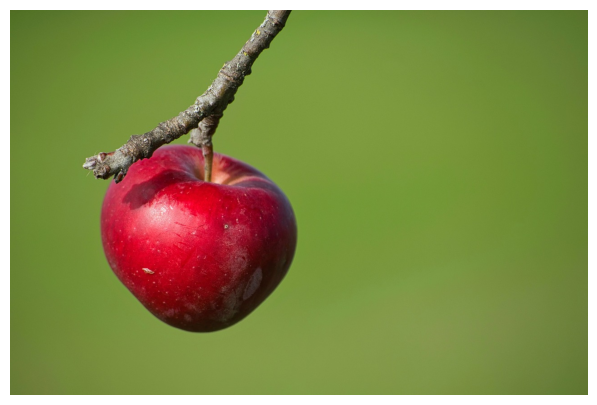

In [3]:
img = cv2.imread('../imgs/apple.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Canais RGB

`cv2.split` separa os canais. A ordem no OpenCV é B, G, R.

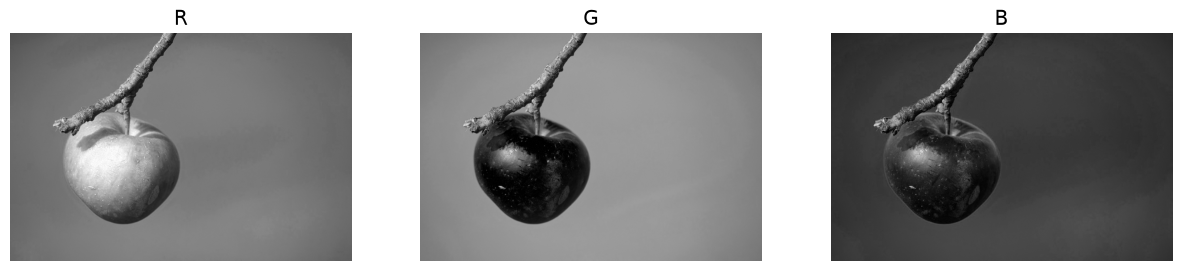

In [4]:
b, g, r = cv2.split(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, canal, nome in zip(axes, [r, g, b], ['R', 'G', 'B']):
    ax.imshow(canal, cmap='gray')
    ax.set_title(nome)
    ax.axis('off')
plt.show()

Uma regra de limiar direta sobre os canais RGB é sensível à iluminação: sombra e reflexo alteram os três canais simultaneamente, e a máscara resultante apresenta descontinuidades.

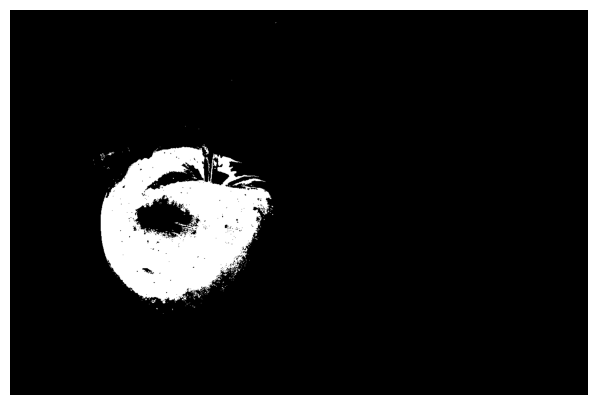

In [5]:
mask_rgb = ((r > 120) & (g < 100) & (b < 100)).astype(np.uint8) * 255

plt.imshow(mask_rgb, cmap='gray')
plt.axis('off')
plt.show()

## Distribuição dos pixels em RGB e HSV

Cada pixel é um ponto em um espaço tridimensional. A visualização abaixo apresenta os mesmos pixels nos dois sistemas de coordenadas.

In [6]:
from matplotlib import colors

maca = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
amostra = maca[::4, ::4]
r, g, b = cv2.split(amostra)

pixel_colors = amostra.reshape((-1, 3))
norm = colors.Normalize(vmin=-1.0, vmax=1.0)
norm.autoscale(pixel_colors)
pixel_colors = norm(pixel_colors).tolist()

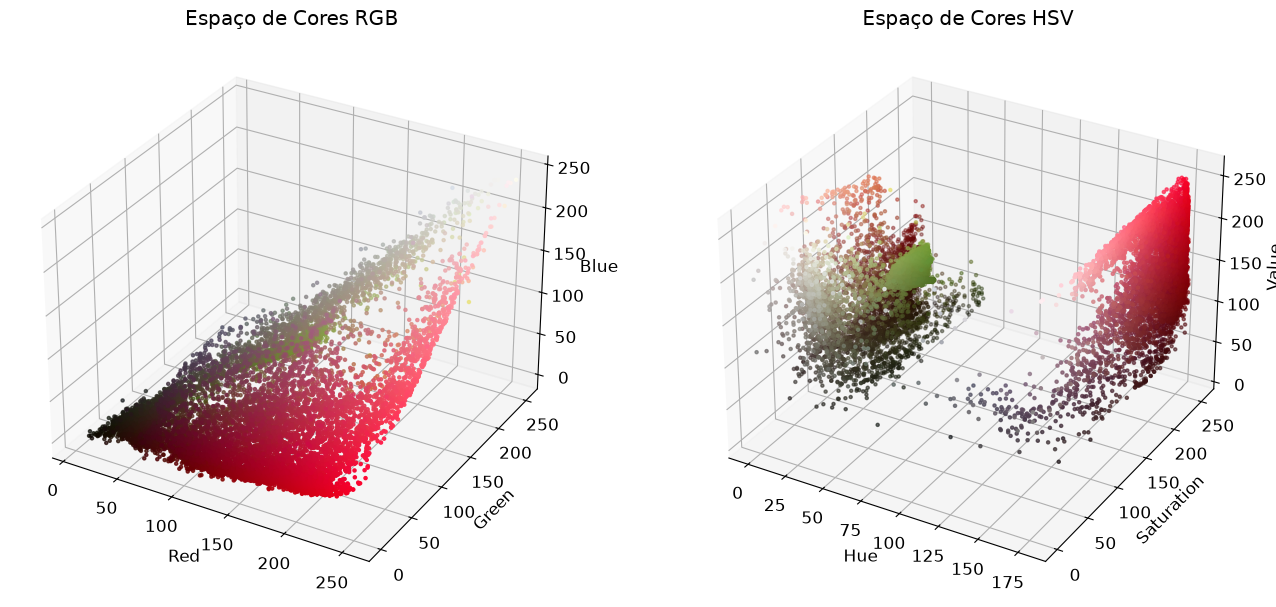

In [7]:
fig = plt.figure(figsize=(16, 8))

axis_rgb = fig.add_subplot(1, 2, 1, projection="3d")
axis_rgb.scatter(r.flatten(), g.flatten(), b.flatten(),
                 facecolors=pixel_colors, marker=".")
axis_rgb.set_xlabel("Red")
axis_rgb.set_ylabel("Green")
axis_rgb.set_zlabel("Blue")
axis_rgb.set_title("Espaço de Cores RGB")

hsv_maca = cv2.cvtColor(amostra, cv2.COLOR_RGB2HSV)
hh, ss, vv = cv2.split(hsv_maca)

axis_hsv = fig.add_subplot(1, 2, 2, projection="3d")
axis_hsv.scatter(hh.flatten(), ss.flatten(), vv.flatten(),
                 facecolors=pixel_colors, marker=".")
axis_hsv.set_xlabel("Hue")
axis_hsv.set_ylabel("Saturation")
axis_hsv.set_zlabel("Value")
axis_hsv.set_title("Espaço de Cores HSV")

plt.show()

No RGB, a variação de iluminação desloca os pixels do objeto ao longo da diagonal do cubo. No HSV, a cor concentra-se no matiz (H) e a iluminação fica restrita a S e V.

No OpenCV: **H de 0 a 179**, **S e V de 0 a 255**. O matiz é uma coordenada angular; o vermelho ocupa as duas extremidades do eixo H.

## Canais HSV

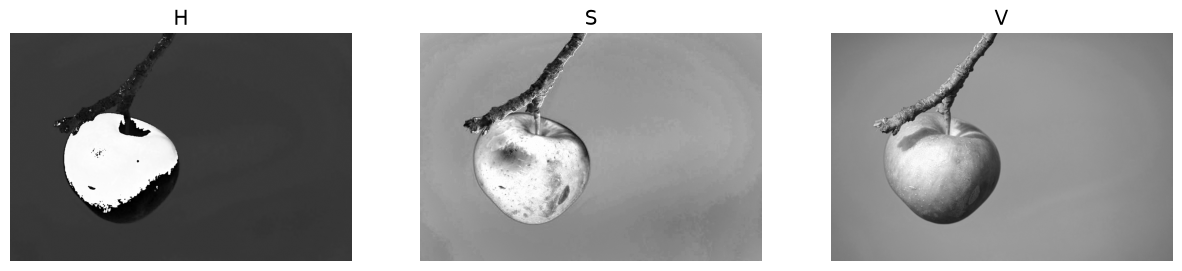

In [8]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, canal, nome in zip(axes, [h, s, v], ['H', 'S', 'V']):
    ax.imshow(canal, cmap='gray')
    ax.set_title(nome)
    ax.axis('off')
plt.show()

## Segmentação por matiz

`cv2.inRange` produz uma máscara binária a partir de limites inferior e superior em HSV. Para o vermelho, são necessárias duas faixas de matiz, combinadas com `cv2.bitwise_or`.

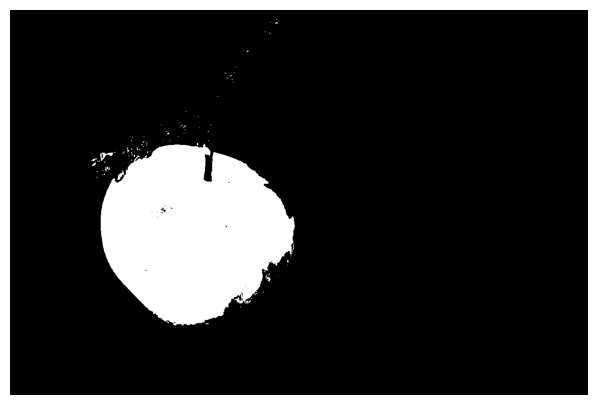

In [9]:
m1 = cv2.inRange(hsv, (0, 40, 40), (10, 255, 255))
m2 = cv2.inRange(hsv, (160, 40, 40), (179, 255, 255))
mask = cv2.bitwise_or(m1, m2)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

Pós-processamento: o fechamento morfológico preenche descontinuidades internas da máscara e a seleção do maior contorno descarta regiões espúrias. O tratamento formal das operações morfológicas é objeto de disciplina posterior.

In [10]:
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))

cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_final = np.zeros_like(mask)
cv2.drawContours(mask_final, [max(cnts, key=cv2.contourArea)], -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(853, 1280), dtype=uint8)

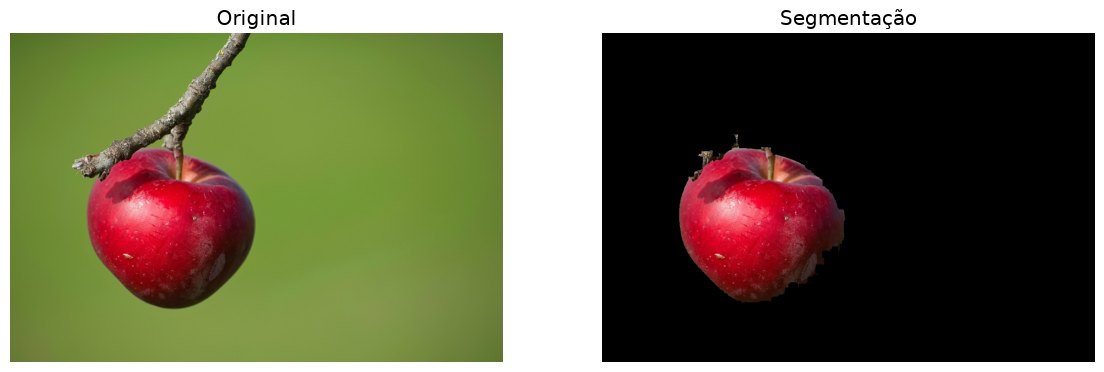

In [11]:
res = cv2.bitwise_and(img, img, mask=mask_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
axes[1].set_title('Segmentação')
for ax in axes:
    ax.axis('off')
plt.show()